# EDA Yoochoose Dataset

Zakres notebooka:
- tylko surowe pliki `clicks`, `buys`, `test`
- bez preprocessingu, splitów i feature engineeringu
- cel: rozpoznać typy danych, strukturę rekordów i różnice między plikami

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

parent_dir = str(Path().resolve().parents[0])

sys.path.insert(0, parent_dir)


In [2]:
from src.utlis import get_project_root

raw_dir = get_project_root() / "data" / "raw"
raw_dir

WindowsPath('C:/UWR AI/SEMESTR II/ADM/adm-project-tgnn/data/raw')

In [8]:
files = {
    "clicks": raw_dir / "yoochoose-clicks.dat",
    "buys": raw_dir / "yoochoose-buys.dat",
    "test": raw_dir / "yoochoose-test.dat",
}

display(pd.read_csv(files["clicks"], header=None, nrows=1))
display(pd.read_csv(files["buys"], header=None, nrows=1))
display(pd.read_csv(files["test"], header=None, nrows=1))

,0,1,2,3
0,1,2014-04-07T10:51:09.277Z,214536502,0


,0,1,2,3,4
0,420374,2014-04-06T18:44:58.314Z,214537888,12462,1


,0,1,2,3
0,5,2014-04-07T17:13:46.713Z,214530776,0


In [10]:
clicks_dtypes = {
    'session_id': 'int32',
    'item_id': 'int32',
    'category': 'str'
}

clicks_raw_df = pd.read_csv(
    files["clicks"], 
    header=None, 
    names=["session_id", "timestamp", "item_id", "category"],
    dtype=clicks_dtypes,
    parse_dates=['timestamp']
)

buys_raw_df = pd.read_csv(
    files["buys"], 
    header=None, 
    names=["session_id", "timestamp", "item_id", "price", "quantity"],
    dtype={'session_id': 'int32', 'item_id': 'int32', 'price': 'int32', 'quantity': 'int32'},
    parse_dates=['timestamp']
)

In [19]:
print(f"Brakujące wartości w clicks_raw_df: {clicks_raw_df.isnull().sum().sum()}")
print(f"Brakujące wartości w buys_raw_df: {buys_raw_df.isnull().sum().sum()}")

Brakujące wartości w clicks_raw_df: 0
Brakujące wartości w buys_raw_df: 0


In [ ]:
print(f"Liczba kliknięć: {len(clicks_raw_df)}")
print(f"Liczba unikalnych sesji (clicks): {clicks_raw_df['session_id'].nunique()}")
print(f"Liczba unikalnych przedmiotów (clicks): {clicks_raw_df['item_id'].nunique()}")
print(f"Liczba transakcji zakupu: {len(buys_raw_df)}")
print(f"Liczba sesji z zakupem: {buys_raw_df['session_id'].nunique()}")

conversion_rate = buys_raw_df['session_id'].nunique() / clicks_raw_df['session_id'].nunique()
print(f"Procent sesji zakończonych zakupem: {conversion_rate * 100:.2f}%")

Liczba kliknięć: 33003944
Liczba unikalnych sesji (clicks): 9249729
Liczba unikalnych przedmiotów (clicks): 52739
Liczba transakcji zakupu: 1150753
Liczba sesji z zakupem: 509696
Procent sesji zakończonych zakupem: 5.51%


In [12]:
session_lengths = clicks_raw_df.groupby('session_id').size()

print("Statystyki długości sesji (liczba kliknięć):")
print(session_lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

Statystyki długości sesji (liczba kliknięć):
count    9.249729e+06
mean     3.568098e+00
std      3.787520e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      4.000000e+00
90%      7.000000e+00
99%      1.800000e+01
max      2.000000e+02
dtype: float64


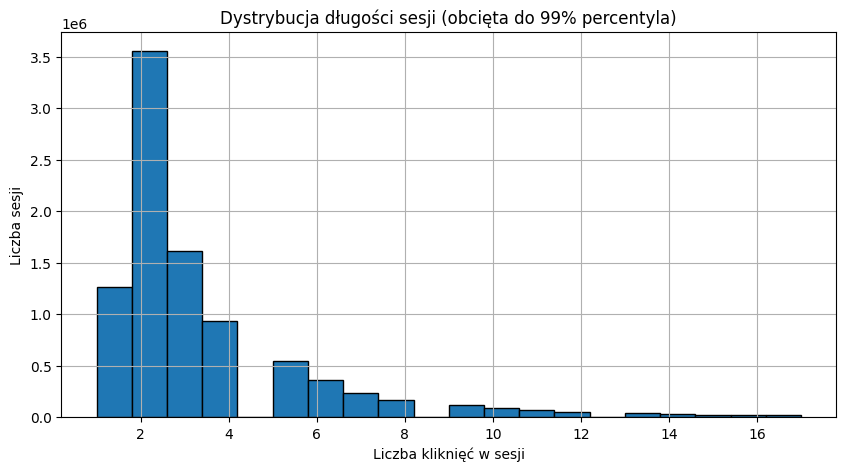

In [20]:
plt.figure(figsize=(10, 5))
session_lengths[session_lengths < session_lengths.quantile(0.99)].hist(bins = 20, edgecolor='black')
plt.title('Dystrybucja długości sesji (obcięta do 99% percentyla)')
plt.xlabel('Liczba kliknięć w sesji')
plt.ylabel('Liczba sesji')
plt.show()

In [16]:
session_times = clicks_raw_df.groupby('session_id')['timestamp'].agg(['min', 'max'])
session_durations = (session_times['max'] - session_times['min']).dt.total_seconds() / 60.0

print("Statystyki czasu trwania sesji (w minutach):")
session_durations.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

Statystyki czasu trwania sesji (w minutach):


count    9.249729e+06
mean     6.360556e+00
std      1.261075e+01
min      0.000000e+00
25%      5.369000e-01
50%      2.132317e+00
75%      6.402200e+00
90%      1.654619e+01
99%      5.883665e+01
max      4.098967e+03
dtype: float64

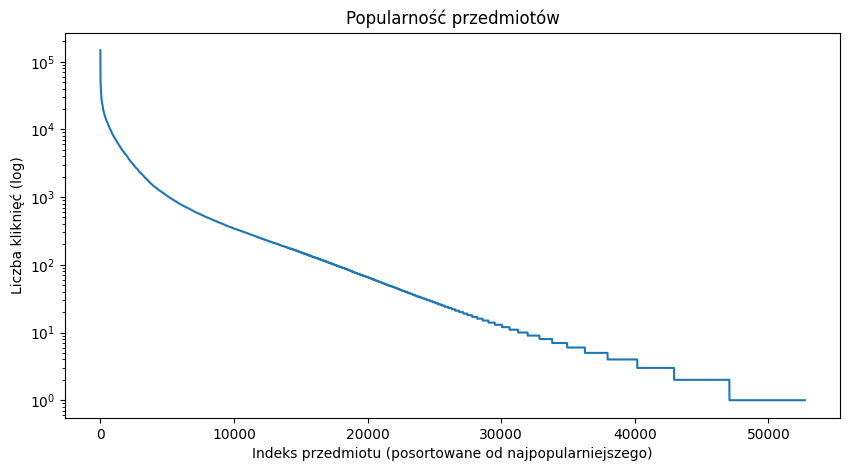

Top 1% najpopularniejszych przedmiotów generuje 34.95% wszystkich kliknięć.


In [ ]:
item_counts = clicks_raw_df['item_id'].value_counts()

plt.figure(figsize=(10, 5))
plt.plot(item_counts.values)
plt.yscale('log')
plt.title('Popularność przedmiotów')
plt.xlabel('Indeks przedmiotu (posortowane od najpopularniejszego)')
plt.ylabel('Liczba kliknięć (log)')
plt.show()

print(f"Top 1% najpopularniejszych przedmiotów generuje {item_counts.iloc[:int(len(item_counts)*0.01)].sum() / len(clicks_raw_df) * 100:.2f}% wszystkich kliknięć.")

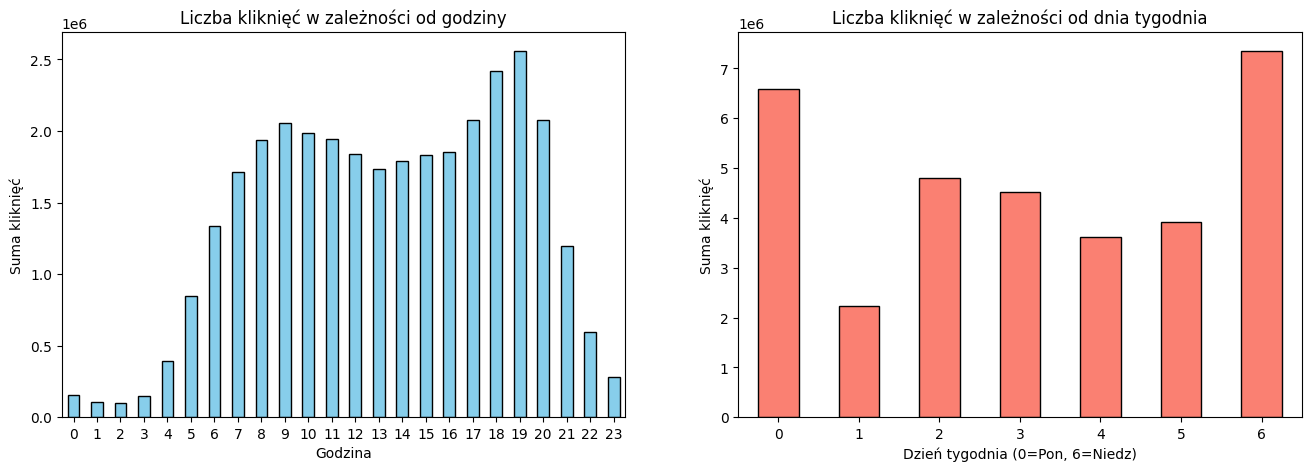

In [29]:
clicks_raw_df['hour'] = clicks_raw_df['timestamp'].dt.hour
clicks_raw_df['day_of_week'] = clicks_raw_df['timestamp'].dt.dayofweek # 0=Poniedziałek, 6=Niedziela

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

clicks_raw_df.groupby('hour').size().plot(kind='bar', ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Liczba kliknięć w zależności od godziny')
ax[0].tick_params(axis='x', rotation=0) 
ax[0].set_xlabel('Godzina')
ax[0].set_ylabel('Suma kliknięć')

clicks_raw_df.groupby('day_of_week').size().plot(kind='bar', ax=ax[1], color='salmon', edgecolor='black')
ax[1].set_title('Liczba kliknięć w zależności od dnia tygodnia')
ax[1].tick_params(axis='x', rotation=0)
ax[1].set_xlabel('Dzień tygodnia (0=Pon, 6=Niedz)')
ax[1].set_ylabel('Suma kliknięć')

plt.show()

In [31]:
print("Przykładowe unikalne wartości w kolumnie category:")
display(clicks_raw_df['category'].unique()[:20])

# Sprawdźmy ile jest braków danych lub dziwnych wartości
print("\nTop 10 najczęstszych kategorii:")
display(clicks_raw_df['category'].value_counts().head(10))

Przykładowe unikalne wartości w kolumnie category:


<StringArray>
[         '0',          'S',          '4',          '7',          '3',
          '2',          '1', '2089286907',          '6',          '5',
         '10',          '9', '2089422131',         '11', '2089538467',
 '2089134472', '2088954951', '2089529540', '2088904854',         '12']
Length: 20, dtype: str


Top 10 najczęstszych kategorii:


category
0    16337653
S    10769610
1     1671754
2     1292249
3      789713
4      480569
5      471923
6      414696
7      389910
9      105282
Name: count, dtype: int64

In [32]:
clicks_sorted = clicks_raw_df.sort_values(['item_id', 'timestamp'])
item_time_diff = clicks_sorted.groupby('item_id')['timestamp'].diff().dt.total_seconds()

print("Statystyki czasu (w sek) między kolejnymi interakcjami tego samego produktu:")
print(item_time_diff.describe(percentiles=[0.5, 0.75, 0.90]))

Statystyki czasu (w sek) między kolejnymi interakcjami tego samego produktu:
count    3.295120e+07
mean     1.449999e+04
std      1.620478e+05
min      0.000000e+00
50%      1.704420e+02
75%      1.525774e+03
90%      1.224037e+04
max      1.531297e+07
Name: timestamp, dtype: float64


In [33]:
clicks_sorted_session = clicks_raw_df.sort_values(['session_id', 'timestamp'])
session_time_diff = clicks_sorted_session.groupby('session_id')['timestamp'].diff().dt.total_seconds()

print("Rozkład opóźnień między kliknięciami wewnątrz sesji:")
print(session_time_diff.describe(percentiles=[0.1, 0.25, 0.5]))
# Ile interakcji ma dokładnie ten sam timestamp (0.0 sekund różnicy)?
print(f"Procent interakcji z delta_t == 0: {(session_time_diff == 0).mean() * 100:.2f}%")

Rozkład opóźnień między kliknięciami wewnątrz sesji:
count    2.375422e+07
mean     1.486054e+02
std      3.261748e+02
min      0.000000e+00
10%      1.024800e+01
25%      2.681900e+01
50%      5.850700e+01
max      3.599995e+03
Name: timestamp, dtype: float64
Procent interakcji z delta_t == 0: 0.00%


In [ ]:
# Ile unikalnych sesji połączonych jest z danym przedmiotem
item_degree = clicks_raw_df.groupby('item_id')['session_id'].nunique()
print("Statystyki stopnia węzłów (Item Degree Distribution):")
print(item_degree.describe(percentiles=[0.5, 0.75, 0.9, 0.99]))

In [34]:
train_items = set(clicks_raw_df['item_id'].unique())
test_items = set(test_raw_df['item_id'].unique())

cold_start_items = test_items - train_items
print(f"Liczba unikalnych przedmiotów w teście: {len(test_items)}")
print(f"Liczba całkowicie nowych przedmiotów w teście (Cold Start): {len(cold_start_items)}")
print(f"Procent 'nowych' przedmiotów: {len(cold_start_items) / len(test_items) * 100:.2f}%")

Liczba unikalnych przedmiotów w teście: 42155
Liczba całkowicie nowych przedmiotów w teście (Cold Start): 1548
Procent 'nowych' przedmiotów: 3.67%


In [35]:
# Sprawdzenie spójności ID
buy_sessions = set(buys_raw_df['session_id'].unique())
click_sessions = set(clicks_raw_df['session_id'].unique())

orphan_buy_sessions = buy_sessions - click_sessions
print(f"Liczba sesji zakupowych bez odpowiadających im kliknięć: {len(orphan_buy_sessions)}")

Liczba sesji zakupowych bez odpowiadających im kliknięć: 0
